In [9]:
import re
import time
import abc
import warnings
import json
import os
import functools
import subprocess
from pathlib import Path
from tqdm.contrib import tzip

import torch
import torchgeo
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Optional, Tuple, cast, Union, Iterator
from rtree.index import Index, Property
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import geopandas as gpd
import rasterio
import timm

import torch.nn.functional as F
import torchvision.transforms as Tr
from torch.optim import Adam
from transformers import AutoVideoProcessor, AutoModel
from kornia.augmentation import AugmentationSequential
from torch.utils.data import DataLoader, Sampler
from torchgeo.datasets import RasterDataset, stack_samples, BoundingBox, GeoDataset
from torchgeo.samplers import GridGeoSampler, RandomGeoSampler
from torchgeo.samplers.constants import Units
from torchgeo.samplers.utils import _to_tuple, get_random_bounding_box, tile_to_chips
import torch.optim.lr_scheduler as lr_scheduler

from utils.train_utils import *
os.chdir("D:/githubs/vjepa2")
#os.chdir(os.path.join(os.getcwd(), ".."))
import src.datasets.utils.video.transforms as video_transforms
import src.datasets.utils.video.volume_transforms as volume_transforms
from src.models.attentive_pooler import AttentiveClassifier
from src.models.vision_transformer import vit_giant_xformers_rope


from src.Prithvi.Prithvi_run_inference import MaskedAutoencoderViT
from DOFA.models_dwv import vit_base_patch16

np.random.seed(42)
torch.manual_seed(42)

In [10]:
IMAGENET_DEFAULT_MEAN = (0.485*255, 0.456*255, 0.406*255)
IMAGENET_DEFAULT_STD = (0.229*255, 0.224*255, 0.225*255)

In [ ]:
Nb_dates = 6
extensions = ('.tif', '.tiff', '.TIF', '.TIFF')
img_dir = "D:/Phenologie/DL_Phenophases/data/Paracou/img"
img_files = sorted([file for file in os.listdir(img_dir) if file.endswith(extensions) and "mask" not in file])
print(img_files)
dates_data_df = pd.DataFrame({'img':img_files})

start = int(Nb_dates/2)
end = len(dates_data_df) - int((Nb_dates-1)/2)

In [ ]:
"""
# HuggingFace model repo name
hf_model_name = (
    "facebook/vjepa2-vitg-fpc64-384"  # Replace with your favored model, e.g. facebook/vjepa2-vitg-fpc64-384
)
# Path to local PyTorch weights
pt_model_path = "YOUR_MODEL_PATH"

# Initialize the HuggingFace model, load pretrained weights
model_hf = AutoModel.from_pretrained(hf_model_name)
model_hf.cuda().eval()
"""

def load_pretrained_vjepa_pt_weights(model, pretrained_weights):
    # Load weights of the VJEPA2 encoder
    # The PyTorch state_dict is already preprocessed to have the right key names
    pretrained_dict = torch.load(pretrained_weights, weights_only=True, map_location="cpu")["encoder"]
    pretrained_dict = {k.replace("module.", ""): v for k, v in pretrained_dict.items()}
    pretrained_dict = {k.replace("backbone.", ""): v for k, v in pretrained_dict.items()}
    msg = model.load_state_dict(pretrained_dict, strict=False)
    print("Pretrained weights found at {} and loaded with msg: {}".format(pretrained_weights, msg))


def load_pretrained_vjepa_classifier_weights(model, pretrained_weights):
    # Load weights of the VJEPA2 classifier
    # The PyTorch state_dict is already preprocessed to have the right key names
    pretrained_dict = torch.load(pretrained_weights, weights_only=True, map_location="cpu")["classifiers"][0]
    pretrained_dict = {k.replace("module.", ""): v for k, v in pretrained_dict.items()}
    msg = model.load_state_dict(pretrained_dict, strict=False)
    print("Pretrained weights found at {} and loaded with msg: {}".format(pretrained_weights, msg))


def build_pt_video_transform(img_size):
    short_side_size = int(256.0 / 224 * img_size)
    # Eval transform has no random cropping nor flip
    eval_transform = video_transforms.Compose(
        [
            video_transforms.Resize(short_side_size, interpolation="bilinear"),
            video_transforms.CenterCrop(size=(img_size, img_size)),
            volume_transforms.ClipToTensor(),
            video_transforms.Normalize(mean=IMAGENET_DEFAULT_MEAN, std=IMAGENET_DEFAULT_STD),
        ]
    )
    return eval_transform


def forward_vjepa(imgs, model):
    # Run a sample inference with VJEPA
    print(imgs.shape)
    with torch.inference_mode():
        # Read and pre-process the image
        # video = get_video()  # T x H x W x C
        # video = torch.from_numpy(video).permute(0, 3, 1, 2)  # T x C x H x W
        # x = transform(video).cuda().unsqueeze(0)
        # Extract the patch-wise features from the last layer
        #imgs = torch.einsum('btchw->bcthw', imgs)  # B x T x C x H x W -> B x C x T x H x W
        out_patch_features = model(imgs)
        #out_patch_features_hf = model_hf.get_vision_features(x_hf)

    return out_patch_features


def get_vjepa_classification_results(classifier, out_patch_features):
    PHENO_CLASSES = json.load(open("pheno_classes.json", "r"))

    with torch.inference_mode():
        out_classifier = classifier(out_patch_features)
    preds = out_classifier.argmax(1)
    for pred in preds.detach().cpu().numpy():
        print(PHENO_CLASSES[str(pred)])

    return

### Prithvi multiple dates

In [21]:
def forward_vjepa(imgs, model):
    print(imgs.shape)
    with torch.inference_mode():
        imgs = torch.einsum('btchw->bcthw', imgs)  # B x T x C x H x W -> B x C x T x H x W
        out_patch_features = model(imgs)
        #out_patch_features_hf = model_hf.get_vision_features(x_hf)

    return out_patch_features

In [ ]:
targSize = 224
tile_size = 112
sep_dates = True

decoder_depth=8
decoder_embed_dim=512
decoder_num_heads=16
depth=12
embed_dim=768
in_chans=3  #len(band_indices) if band_indices is not None else 3
num_frames=Nb_dates
num_heads=12
patch_size=16
tubelet_size=2

encoder = MaskedAutoencoderViT(
            img_size=targSize,
            patch_size=patch_size,
            num_frames=num_frames,
            tubelet_size=tubelet_size,
            in_chans=in_chans,
            embed_dim=embed_dim,
            depth=depth,
            num_heads=num_heads,
            decoder_embed_dim=decoder_embed_dim,
            decoder_depth=decoder_depth,
            decoder_num_heads=decoder_num_heads,
            mlp_ratio=4.0,
            norm_layer=functools.partial(torch.nn.LayerNorm, eps=1e-6),
            norm_pix_loss=False,
        )
state_dict = torch.load("D:/githubs/Prithvi_100M/Prithvi_100M.pt")
del state_dict["pos_embed"]
del state_dict["decoder_pos_embed"]
del state_dict['patch_embed.proj.weight']
del state_dict['patch_embed.proj.bias']
del state_dict["decoder_pred.weight"]
del state_dict["decoder_pred.bias"]
encoder.load_state_dict(state_dict, strict = False)
encoder.cuda()

classifier = (
    AttentiveClassifier(embed_dim=encoder.decoder_pred.out_features, num_heads=16, depth=4, num_classes=4).cuda().eval()
)

In [ ]:
transforms=DictTransform(AugmentationSequential(T.Resize((targSize, targSize)), T.Normalize(mean=IMAGENET_DEFAULT_MEAN, std=IMAGENET_DEFAULT_STD), data_keys=["image"]))

for k in range(start, start+1): #end
    filepaths = [os.path.join(img_dir, dates_data_df['img'][i]) for i in range(k-int(Nb_dates/2), k+int((Nb_dates+1)/2))]
    print("filepaths : ", filepaths)
    inf_dataset = MultiDateRGBDataset(filepaths, transforms=transforms, sep_dates=False)

sampler = RandomGeoSampler(inf_dataset, size=tile_size, length=10)
dataloader = DataLoader(inf_dataset, batch_size=1, sampler=sampler, collate_fn=stack_samples, shuffle=False)
for batch in dataloader:
    img = batch['image'].cuda()
    feat = forward_vjepa(img, encoder)       #out = B x num_patches x embed_dim = B x 14*14*nb_dates/tubelet_size x 1536 = B x 588 x 1536
    #print(feat[1].shape)
    get_vjepa_classification_results(classifier, feat[1])
    

### Dinov2 Single date

In [13]:
def forward_vjepa(imgs, model):
    with torch.inference_mode():
        out_patch_features = model.forward_features(imgs)
        #out_patch_features_hf = model_hf.get_vision_features(x_hf)

    return out_patch_features

In [14]:
img_dir = "Z:/shared/PhenOBS_Africa/Mbalmayo/Mosa_rect_Oct2025"
targSize = 518
tile_size = 74

transforms = DictTransform(AugmentationSequential(T.Resize((targSize, targSize)), T.Normalize(mean=IMAGENET_DEFAULT_MEAN, std=IMAGENET_DEFAULT_STD), data_keys=["image"]))

encoder = timm.create_model('vit_base_patch14_dinov2', pretrained=True)
encoder.cuda()

classifier = (
    AttentiveClassifier(embed_dim=encoder.num_features, num_heads=16, depth=4, num_classes=4).cuda().eval()
)
classifier.cuda()

AttentiveClassifier(
  (pooler): AttentivePooler(
    (cross_attention_block): CrossAttentionBlock(
      (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (xattn): CrossAttention(
        (q): Linear(in_features=768, out_features=768, bias=True)
        (kv): Linear(in_features=768, out_features=1536, bias=True)
      )
      (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
    (blocks): ModuleList(
      (0-2): 3 x Block(
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=768, out_features=768, b

In [ ]:
files_list = [file for file in os.listdir(img_dir) if file.endswith(extensions)]
print(files_list)
for f in files_list[:1]:
    print(f)
    inf_dataset = RobustGeoDataset(RasterDataset(paths=[os.path.join(img_dir, f)], transforms=transforms))
    sampler = RandomGeoSampler(inf_dataset, size=tile_size, length=10)
    dataloader = DataLoader(inf_dataset, batch_size=1, sampler=sampler, collate_fn=stack_samples, shuffle=False)
    for batch in dataloader:
        img = batch['image'].cuda()
        feat = forward_vjepa(img, encoder)       #out = B x num_patches x embed_dim = B x 14*14 x 768
        print(feat.shape)
        get_vjepa_classification_results(classifier, feat[:, 1:])

### Embeddings pré-calculation

In [3]:
shp_path = "D:/Phenologie/DL_Phenophases/data/Mbalmayo/Mbalmayo_crowns_2024_04_05_32632.gpkg"
crowns_shp = gpd.read_file(shp_path)
for i in range(len(crowns_shp)):
    if crowns_shp['geometry'][i].geom_type == 'MultiPolygon':
        crowns_shp['geometry'][i] = crowns_shp['geometry'][i].geoms[0]

list_rois = [polygon_to_bbox(poly) for poly in crowns_shp['geometry']]

extensions = ('.tif', '.tiff', '.TIF', '.TIFF')
img_dir = "Z:/shared/PhenOBS_Africa/Mbalmayo/Mosa_rect_Oct2025"
Mbal24_dates = [f for f in os.listdir(img_dir) if f.endswith(extensions)][34:58]

#### DOFA

In [4]:
targSize = 224
tile_size = 112
wavelengths = [0.665, 0.56, 0.49]

transforms = DictTransform(AugmentationSequential(Tr.Resize((targSize, targSize)), Tr.Normalize(mean=IMAGENET_DEFAULT_MEAN, std=IMAGENET_DEFAULT_STD), data_keys=["image"]))

encoder = vit_base_patch16(global_pool=False, img_size=224)
state_dict = torch.load("Z:/users/HadrienTulet/DL_pheno/models/DOFA/checkpoints/DOFA_ViT_base_e100.pth")
encoder.load_state_dict(state_dict, strict=False)
encoder.head = nn.Identity()
encoder.cuda()

OFAViT(
  (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
  (patch_embed): Dynamic_MLP_OFA(
    (weight_generator): TransformerWeightGenerator(
      (transformer_encoder): TransformerEncoder(
        (layers): ModuleList(
          (0): TransformerEncoderLayer(
            (self_attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
            )
            (linear1): Linear(in_features=128, out_features=2048, bias=True)
            (dropout): Dropout(p=False, inplace=False)
            (linear2): Linear(in_features=2048, out_features=128, bias=True)
            (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (dropout1): Dropout(p=False, inplace=False)
            (dropout2): Dropout(p=False, inplace=False)
          )
        )
      )
      (fc_weight): Linear(in_features=128, out_features=196

#### Dinov2

In [74]:
targSize = 518
tile_size = 74

transforms = DictTransform(AugmentationSequential(T.Resize((targSize, targSize)), T.Normalize(mean=IMAGENET_DEFAULT_MEAN, std=IMAGENET_DEFAULT_STD), data_keys=["image"]))

encoder = timm.create_model('vit_base_patch14_dinov2', pretrained=True)
encoder.cuda()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=Fal

#### Croisement avec labels

In [34]:
labels_df = pd.read_excel("C:/Users/tulet/Downloads/labeling_files.xlsx", sheet_name="Mbalmayo")            #"D:/Phenologie/DL_Phenophases/data/labeling_files_20250712.xlsx"

labels_df.rename(columns={f'{labels_df.columns[2]}' : 'fid_1'}, inplace=True)
df_cols = labels_df.columns
labels_df = labels_df.applymap(lambda x: x.replace(';', '') if type(x)==str else x)
labels_df['id'] = labels_df['fid_1']
df_cols = labels_df.columns
labels_df.columns = list(df_cols[:9]) + [dt.replace('_', '') for dt in df_cols[9:76]] + list(df_cols[76:])

merged_df_full = pd.merge(crowns_shp, labels_df, how = 'inner', on = 'id')
merged_df_full['bboxes'] = [polygon_to_bbox(geom) for geom in merged_df_full['geometry']]
merged_df_full

C:\Users\tulet\AppData\Local\Temp\ipykernel_6156\758921534.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  labels_df = labels_df.applymap(lambda x: x.replace(';', '') if type(x)==str else x)


,id,id_n,tx_sp_lvl,tax_gen,tax_fam,idtax_f,plot_name,date,encoder,tag_plot,...,20250712,Comm,shp_modif,obs_shp_modif,date_shp_modif,sp_check,Mavic 3,Lianas,Chablis,bboxes
0,1.0,333960.0,Pterocarpus soyauxii,Pterocarpus,Fabaceae,6725.0,mbalmayo_pheno_observatory,2023-07-02T12:08:20.437,10,NaN,...,L,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"BoundingBox(minx=771750.5547774422, maxx=77176..."
1,2.0,333961.0,Distemonanthus benthamianus,Distemonanthus,Fabaceae,2977.0,mbalmayo_pheno_observatory,2023-07-02T12:07:45.642,10,NaN,...,L,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"BoundingBox(minx=771766.7631027646, maxx=77178..."
2,3.0,333962.0,Cylicodiscus gabunensis,Cylicodiscus,Fabaceae,4840.0,mbalmayo_pheno_observatory,2023-07-02T12:12:02.863,10,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"BoundingBox(minx=771716.9939082317, maxx=77175..."
3,4.0,333963.0,Chrysophyllum lacourtianum,Chrysophyllum,Sapotaceae,58560.0,mbalmayo_pheno_observatory,2023-07-02T12:19:57.726,10,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"BoundingBox(minx=771712.1690053209, maxx=77173..."
4,5.0,333964.0,Lophira alata,Lophira,Ochnaceae,1690.0,mbalmayo_pheno_observatory,2023-07-02T11:54:15.244,10,NaN,...,L,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"BoundingBox(minx=771717.8736656002, maxx=77174..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2027,2604.0,344039.0,Parkia filicoidea,Parkia,Fabaceae,1645.0,mbalmayo_pheno_observatory,2024-03-28T13:33:46.920,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"BoundingBox(minx=771807.867137525, maxx=771824..."
2028,2605.0,344040.0,Quassia gabonensis,Quassia,Simaroubaceae,60603.0,mbalmayo_pheno_observatory,2024-03-28T13:35:36.942,1,NaN,...,L,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"BoundingBox(minx=771806.0798850631, maxx=77181..."
2029,2606.0,344041.0,Erythrophleum suaveolens,Erythrophleum,Fabaceae,748.0,mbalmayo_pheno_observatory,2024-03-28T13:41:11.413,1,NaN,...,L,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"BoundingBox(minx=771780.7829018908, maxx=77179..."
2030,2607.0,344042.0,Piptadeniastrum africanum,Piptadeniastrum,Fabaceae,1647.0,mbalmayo_pheno_observatory,2024-03-28T13:42:18.101,1,NaN,...,L,enliané,NaN,NaN,NaN,NaN,NaN,1.0,NaN,"BoundingBox(minx=771756.9928486992, maxx=77178..."


In [ ]:
out_dir = "Z:/users/HadrienTulet/DL_pheno/vjepa/DOFA_Mbal24_patchtokens"
out_dir_cls = "Z:/users/HadrienTulet/DL_pheno/vjepa/DOFA_Mbal24_clstokens"

print(Mbal24_dates)
for file in Mbal24_dates:
    print(file)
    date = file.split("_")[0]
    red_df = merged_df_full.loc[merged_df_full[date].isin(['L', 'D', 'F'])]
    list_rois = list(red_df['bboxes'])
    inf_dataset = RobustGeoDataset(RasterDataset(paths=[os.path.join(img_dir, file)], transforms=transforms))
    sampler = MultipleGridGeoSampler(inf_dataset, size=tile_size, stride=tile_size, roi_bounds=list_rois)
    dataloader = DataLoader(inf_dataset, batch_size=1, sampler=sampler, collate_fn=skip_none_collate, shuffle=False)
    
    N = len(dataloader)
    blank = np.zeros((N, int((targSize/encoder.patch_embed.patch_size[0])**2), 768), dtype=np.float16)          #encoder.num_features
    blank_cls = np.zeros((N, 768), dtype=np.float16)
    print(blank.shape)
    for i, batch in enumerate(dataloader):
        if batch is None:
            continue
        else:
            print(f"{i/N:.2%}", end="\r")
            bboxes = batch['bbox']
            img = batch['image'].cuda()
            with torch.inference_mode():
                feat = encoder.forward_features(img, wave_list = wavelengths)                #out = B x num_patches x embed_dim = B x 14*14 x 768
                feat = feat.detach().cpu().numpy().astype(np.float16).squeeze(0)
                blank[i] = feat[1:]
                blank_cls[i] = feat[1]
    np.save(os.path.join(out_dir, f"{date}_features.npy"), blank)
    np.save(os.path.join(out_dir_cls, f"{date}_clstokens.npy"), blank_cls)

#### Processing

In [ ]:
out_dir = "Z:/users/HadrienTulet/DL_pheno/vjepa/DOFA_Mbal24_patchtokens"
out_dir_cls = "Z:/users/HadrienTulet/DL_pheno/vjepa/DOFA_Mbal24_clstokens"

print(Mbal24_dates)
for file in Mbal24_dates:
    print(file)
    inf_dataset = RobustGeoDataset(RasterDataset(paths=[os.path.join(img_dir, file)], transforms=transforms))
    sampler = MultipleGridGeoSampler(inf_dataset, size=tile_size, stride=tile_size, roi_bounds=list_rois)
    dataloader = DataLoader(inf_dataset, batch_size=1, sampler=sampler, collate_fn=skip_none_collate, shuffle=False)
    date = file.split("_")[0]
    N = len(dataloader)
    blank = np.zeros((N, int((targSize/encoder.patch_embed.patch_size[0])**2), 768), dtype=np.float16)          #encoder.num_features
    blank_cls = np.zeros((N, 768), dtype=np.float16)
    print(blank.shape)
    for i, batch in enumerate(dataloader):
        if batch is None:
            continue
        else:
            print(f"{i/N:.2%}", end="\r")
            bboxes = batch['bbox']
            img = batch['image'].cuda()
            with torch.inference_mode():
                feat = encoder.forward_features(img, wave_list = wavelengths)                #out = B x num_patches x embed_dim = B x 14*14 x 768
                feat = feat.detach().cpu().numpy().astype(np.float16).squeeze(0)
                blank[i] = feat[1:]
                blank_cls[i] = feat[1]
    np.save(os.path.join(out_dir, f"{date}_features.npy"), blank)
    np.save(os.path.join(out_dir_cls, f"{date}_clstokens.npy"), blank_cls)

##### Add bboxes

In [79]:
targSize = 224
tile_size = 112
transforms=DictTransform(AugmentationSequential(Tr.Resize((targSize, targSize)), Tr.Normalize(mean=IMAGENET_DEFAULT_MEAN, std=IMAGENET_DEFAULT_STD), data_keys=["image"]))

out_dir = "D:/Phenologie/DL_Phenophases/vjepa/bboxes"
sp_bb = []
file = Mbal24_dates[0]
inf_dataset = RobustGeoDataset(RasterDataset(paths=[os.path.join(img_dir, file)], transforms=transforms))
sampler = MultipleGridGeoSampler(inf_dataset, size=tile_size, stride=tile_size, roi_bounds=list_rois)

all_bboxes = []
for hit in sampler.hits:
    bounds = hit
    rows, cols = tile_to_chips(bounds, sampler.size, sampler.stride)
    mint = bounds.mint
    maxt = bounds.maxt

    # For each row...
    for i in range(rows):
        miny = bounds.miny + i * sampler.stride[0]
        maxy = miny + sampler.size[0]

        # For each column...
        for j in range(cols):
            minx = bounds.minx + j * sampler.stride[1]
            maxx = minx + sampler.size[1]

            all_bboxes.append(BoundingBox(minx, maxx, miny, maxy, mint, maxt))

print(len(all_bboxes))

23483


In [ ]:
arr = np.array([[b.minx, b.maxx, b.miny, b.maxy, b.mint, b.maxt] for b in all_bboxes])
np.save("D:/Phenologie/DL_Phenophases/vjepa/bboxes/all_bboxes.npy", arr)

q = arr.shape[0] // 23
print(q)
for i in range(23):
    red_arr = arr[i*q:(i+1)*q]
    print(red_arr.shape)
    np.save(f"D:/Phenologie/DL_Phenophases/vjepa/bboxes/chunk_{i}_bboxes.npy", red_arr)

#### Reshape features spatially

In [3]:
feat_dir = "Z:/users/HadrienTulet/DL_pheno/vjepa/DOFA_Mbal24_patchtokens"
output_dir = Path("D:/Phenologie/DL_Phenophases/vjepa/tokens_DOFA_Mbal24_reshape")
k = 23

input_dir  = Path(feat_dir)
output_dir.mkdir(parents=True, exist_ok=True)

arrays = [np.load(os.path.join(input_dir, f), mmap_mode='r') for f in os.listdir(input_dir)]

N = arrays[0].shape[0]
assert all(a.shape[0] == N for a in arrays), "All dates must have the same N"
assert N % k == 0, f"N={N} is not evenly divisible by k={k}"

chunk_size = N // k
print(f"N={N}, k={k}, chunk_size={chunk_size}")

for i in range(k):
    out_path = os.path.join(output_dir, f"chunk_{i}_features.npy")
    print(out_path)
    if not os.path.exists(out_path):
        start, end = i * chunk_size, (i + 1) * chunk_size

        chunk = np.stack([a[start:end] for a in arrays], axis=0)

        np.save(out_path, chunk)
        print(f"  Saved")

print("Done.")

N=23483, k=23, chunk_size=1021
D:\Phenologie\DL_Phenophases\vjepa\tokens_DOFA_Mbal24_reshape\chunk_0_features.npy
D:\Phenologie\DL_Phenophases\vjepa\tokens_DOFA_Mbal24_reshape\chunk_1_features.npy
D:\Phenologie\DL_Phenophases\vjepa\tokens_DOFA_Mbal24_reshape\chunk_2_features.npy
D:\Phenologie\DL_Phenophases\vjepa\tokens_DOFA_Mbal24_reshape\chunk_3_features.npy
D:\Phenologie\DL_Phenophases\vjepa\tokens_DOFA_Mbal24_reshape\chunk_4_features.npy
D:\Phenologie\DL_Phenophases\vjepa\tokens_DOFA_Mbal24_reshape\chunk_5_features.npy
  Saved
D:\Phenologie\DL_Phenophases\vjepa\tokens_DOFA_Mbal24_reshape\chunk_6_features.npy
  Saved
D:\Phenologie\DL_Phenophases\vjepa\tokens_DOFA_Mbal24_reshape\chunk_7_features.npy
  Saved
D:\Phenologie\DL_Phenophases\vjepa\tokens_DOFA_Mbal24_reshape\chunk_8_features.npy
  Saved
D:\Phenologie\DL_Phenophases\vjepa\tokens_DOFA_Mbal24_reshape\chunk_9_features.npy
  Saved
D:\Phenologie\DL_Phenophases\vjepa\tokens_DOFA_Mbal24_reshape\chunk_10_features.npy
  Saved
D:\Phen

### Auto-supervised training

In [11]:
loss_fn = torch.nn.L1Loss()

In [44]:
class TemporalAggregator(nn.Module):                # With absolute sinusoidal pos embedding
    def __init__(self, embed_dim, num_heads=8, num_layers=2, cls = False):
        super().__init__()
        layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, batch_first=True)
        self.embed_dim = embed_dim
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.query = nn.Parameter(torch.randn(1, 1, embed_dim))  # learned aggregation token
        self.cls = cls

    def get_sinusoidal_encoding(self, T, device):           # absolute encoding
        """Computes sinusoidal positional encoding for sequence length T."""
        position = torch.arange(T, device=device).unsqueeze(1)              # (T, 1)                                                            # (embed_dim/2,)
        pe = torch.zeros(T, self.embed_dim, device=device)
        pe[:, 0::2] = torch.sin(position * torch.exp(torch.arange(0, self.embed_dim, 2, device=device) * (-np.log(10000.0) / self.embed_dim)))
        pe[:, 1::2] = torch.cos(position * torch.exp(torch.arange(0, self.embed_dim, 2, device=device) * (-np.log(10000.0) / self.embed_dim)))
        return pe  # (T, D)
    
    def forward(self, x):  # x: (B, T, N, D)
        if not self.cls :
            B, T, N, D = x.shape
            pos_enc = self.get_sinusoidal_encoding(T, x.device)   # (T, D)
            x = x + pos_enc.view(1, T, 1, D)                   
            # Process each spatial token's temporal sequence independently
            x = x.permute(0, 2, 1, 3).reshape(B * N, T, D)  # (B*N, T, D)
            # Prepend learned query token
            q = self.query.expand(B * N, -1, -1)             # (B*N, 1, D)
        else:
            B, T, D = x.shape
            N = 1
            pos_enc = self.get_sinusoidal_encoding(T, x.device)   # (T, D)
            x = x + pos_enc.view(1, T, D)
            q = self.query.expand(B, -1, -1)             # (B, 1, D)
        
        x = torch.cat([q, x], dim=1)                     # (B / B*N, T+1, D)
        
        x = self.transformer(x)                          # (B / B*N, T+1, D)
        x = x[:, 0]                                      # take query token → (B / B*N, D)
        
        return x.reshape(B, D) if self.cls else x.reshape(B, N, D)                        # (B, N, D) / (B, D)

In [41]:
class TemporalAggregator(nn.Module):                # With absolute sinusoidal pos embedding
    def __init__(self, embed_dim, num_heads=8, num_layers=2, cls = False):
        super().__init__()
        layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, batch_first=True)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.query = nn.Parameter(torch.randn(1, 1, embed_dim))  # learned aggregation token
        self.register_buffer("slopes", self._get_alibi_slopes(num_heads), persistent=False)
        self.cls = cls

    @staticmethod
    def _get_alibi_slopes(num_heads):

        def get_slopes_power_of_2(n):
            start = 2 ** (-2 ** -(np.log2(n) - 3))
            ratio = start
            return [start * ratio ** i for i in range(n)]

        if np.log2(num_heads).is_integer():
            slopes = get_slopes_power_of_2(num_heads)
        else:
            # handle non-power-of-2 head counts
            closest_pow2 = 2 ** np.floor(np.log2(num_heads))
            slopes = get_slopes_power_of_2(closest_pow2)
            extra = get_slopes_power_of_2(2 * closest_pow2)[0::2]
            slopes += extra[: num_heads - closest_pow2]
        return torch.tensor(slopes, dtype=torch.float32)  # (num_heads,)
    
    def get_alibi_bias(self, seq_len, device):

        pos = torch.arange(seq_len, device=device)
        rel_pos = pos[None, :] - pos[:, None]              # (T, T), rel_pos[i,j] = j - i
        rel_pos = -rel_pos.abs().float()                   # closer = less negative
        bias = self.slopes.to(device)[:, None, None] * rel_pos[None, :, :]  # (num_heads, T, T)
        return bias
    
    def forward(self, x):  # x: (B, T, N, D)
        if not self.cls :
            B, T, N, D = x.shape
            # Process each spatial token's temporal sequence independently
            x = x.permute(0, 2, 1, 3).reshape(B * N, T, D)  # (B*N, T, D)
            # Prepend learned query token
            q = self.query.expand(B * N, -1, -1)             # (B*N, 1, D)
        else:
            B, T, D = x.shape
            N = 1
            q = self.query.expand(B, -1, -1)             # (B, 1, D)
        
        x = torch.cat([q, x], dim=1)                     # (B / B*N, T+1, D)
        alibi_bias = self.get_alibi_bias(T+1, x.device)   # (num_heads, T+1, T+1)
        # Delete alibi bias for query vector
        alibi_bias[:, 0, :] = 0
        alibi_bias[:, :, 0] = 0
        attn_mask = alibi_bias.unsqueeze(0).expand(B * N, -1, -1, -1).reshape(
            B * N * self.num_heads, T+1, T+1
        )
        x = self.transformer(x, mask = attn_mask)                          # (B / B*N, T+1, D)
        x = x[:, 0]                                      # take query token → (B / B*N, D)
        
        return x.reshape(B, D) if self.cls else x.reshape(B, N, D)

In [42]:
"""
classifier = (
    AttentiveClassifier(embed_dim=768, num_heads=16, depth=4).cuda().eval()
)
classifier.linear = nn.Identity()
classifier = classifier.half()
classifier = classifier.cuda()
"""
classifier = TemporalAggregator(embed_dim = 768, num_heads=16, num_layers=4, cls=True).cuda()#.eval()          # Treats each patch idependently
classifier

TemporalAggregator(
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (linear1): Linear(in_features=768, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=768, bias=True)
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
)

In [39]:
import abc
import os
from tqdm import tqdm
 
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from typing import List, Optional, Tuple, cast, Union, Iterator
from rtree.index import Index, Property
import rasterio

from torch.utils.data import DataLoader, Sampler, Dataset
from torch.optim import Adam
from torchgeo.datasets import RasterDataset, stack_samples, BoundingBox, GeoDataset
from torchgeo.samplers.constants import Units
from torchgeo.samplers.utils import _to_tuple, get_random_bounding_box, tile_to_chips

os.chdir("D:/githubs/vjepa2")

class RandomZeroMask:
    """
    Transform to replace random frames with zeros
    """
    def __init__(self, p=0.05, keep_last_frame = False):
        self.p = p
        self.klf = keep_last_frame

    def __call__(self, x):           # x: (T, N_patches, D) / (T, D)
        T = x.shape[0]
        zero_mask = torch.rand(T) > self.p
        # Do not replace the last frame
        if self.klf:
            zero_mask[-1] = True
        # always keep at least 1 frame
        elif zero_mask.sum() == 0 :
            zero_mask[np.random.randint(T)] = True
        shape = (T,) + (1,)*(len(x.shape)-1)
        return x * zero_mask.view(*shape)

class TileWindowDataset(Dataset):
    """
    Loads one .npy file of shape (T_total, N, N_patches, embed_dim) and
    returns both a time series of feature of size T, and the frame 
    immediately after the window

    Each sample is:
        vec     — (T, N_patches, embed_dim)  input window
        target  — (N_patches, embed_dim)     frame immediately after the window
        tile_idx — int, for debugging / analysis
    """

    def __init__(self, filepath: str, T: Union[int, tuple], transform = None, p: float=0.2):
        # feat_data: (T_total, N, N_patches, embed_dim)
        
        self.data = torch.from_numpy(
            np.load(filepath, mmap_mode='r')
        )
        #self.data = self.data[:, ::10]
        #print(f"{os.path.basename(filepath)} : {self.data.shape}")
        
        self.T       = T
        self.T_total = self.data.shape[0]
        self.N       = self.data.shape[1]
        self.T_max = T[-1] if isinstance(T, tuple) else T
        self.transform = transform

        indices = []
        for n in range(self.N):
            selected_inds = []
            for t in range(self.T_max, self.T_total):           #self.T_total - self.T_max
                if np.random.random()<p:
                    selected_inds.append(t)
            if not selected_inds:
                selected_inds.append(np.random.randint(self.T_max, self.T_total))           #self.T_total - self.T_max
            indices.extend([(n, t) for t in selected_inds])

        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        n, t = self.indices[idx]
        vec    = self.data[t - self.T_max : t, n]       # (T, N_patches, embed_dim)     #[t, t + self.T_max, n]
        target = self.data[t, n]           # (N_patches, embed_dim)                     #[t, n]

        if self.transform is not None:
            vec = self.transform(vec)
        return vec, target

def run_epoch(classifier, loader, optimizer, loss_fn, train: bool, scheduler = None):

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    classifier.train() if train else classifier.eval()
    total_loss, n_steps = 0.0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for vec, target in loader:
            # vec:    (B, T, N_patches, embed_dim)
            # target: (B, N_patches, embed_dim)
            vec    = vec.to(DEVICE)
            target = target.to(DEVICE).detach()     # stop-gradient on target
            predicted = classifier(vec)             # (B, N_patches, embed_dim)
            loss      = loss_fn(predicted, target)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                if scheduler:
                    scheduler.step()

            total_loss += loss.item()
            n_steps    += 1

    return total_loss / n_steps

def train_loop(classifier: nn.Module, feat_dir: str, out_path: str, T: Union[int, tuple], loss_fn: nn.Module, batch_size: int, N_epochs: int, lr: float, p_mask: float = 0.05, n_workers: int = 1):

    def collate_random_T(batch):
        vecs, targets = zip(*batch)
        if isinstance(T, tuple):
            rd_T = np.random.randint(T[0], T[1])
        else:
            rd_T = T
        vecs   = torch.stack([v[-rd_T:] for v in vecs])   # (B, T, N_patches, D)
        targets = torch.stack(list(targets))            # (B, N_patches, D)
        return vecs, targets

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    features_files = sorted(os.listdir(feat_dir))
    sep = int(np.floor(3*len(features_files)/4))
    print(sep)
    train_files = features_files[:sep]#[:1]
    val_files = features_files[sep:]#[:1]
    print("Train files : \n", train_files, "\nVal files : \n", val_files)

    transforms = RandomZeroMask(p=p_mask)
    #transforms = None
    
    optimizer = Adam(classifier.parameters(), lr=lr)
    #scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    scheduler = None
    classifier.to(DEVICE)
    train_losses, val_losses = [], []
    for epoch in range(N_epochs):
        print(f"\nEpoch {epoch+1}/{N_epochs}")

        # Training
        train_loss = 0.0
        print("Train : ")
        for f in tqdm(train_files):
            dataset = TileWindowDataset(os.path.join(feat_dir, f), T=T, transform=transforms)
            loader  = DataLoader(
                dataset,
                batch_size=batch_size,
                shuffle=True,
                collate_fn = collate_random_T,
            )
            train_loss += run_epoch(classifier, loader, optimizer, loss_fn, scheduler=scheduler, train=True)
        train_loss /= max(len(train_files), 1)
        train_losses.append(train_loss)
        # Val
        val_loss = 0.0
        print("\nValidation : ")
        for f in tqdm(val_files):
            dataset = TileWindowDataset(os.path.join(feat_dir, f), T=T, transform=transforms)
            loader  = DataLoader(
                dataset,
                batch_size=batch_size,
                shuffle=False,
                collate_fn = collate_random_T,
            )
            val_loss += run_epoch(classifier, loader, optimizer, loss_fn, scheduler=scheduler, train=False)
        val_loss /= max(len(val_files), 1)

        print(f"  train loss: {train_loss:.6f}  |  val loss: {val_loss:.6f}")

        val_losses.append(val_loss)
        if val_loss == np.min(val_losses):
            torch.save(classifier.state_dict(), out_path)

    X = np.array([i+1 for i in range(N_epochs)])
    plt.plot(X, train_losses)
    plt.plot(X, val_losses)
    plt.show()

    return train_losses, val_losses

17
Train files : 
 ['chunk_0_features.npy', 'chunk_10_features.npy', 'chunk_11_features.npy', 'chunk_12_features.npy', 'chunk_13_features.npy', 'chunk_14_features.npy', 'chunk_15_features.npy', 'chunk_16_features.npy', 'chunk_17_features.npy', 'chunk_18_features.npy', 'chunk_19_features.npy', 'chunk_1_features.npy', 'chunk_20_features.npy', 'chunk_21_features.npy', 'chunk_22_features.npy', 'chunk_2_features.npy', 'chunk_3_features.npy'] 
Val files : 
 ['chunk_4_features.npy', 'chunk_5_features.npy', 'chunk_6_features.npy', 'chunk_7_features.npy', 'chunk_8_features.npy', 'chunk_9_features.npy']

Epoch 1/30
Train : 


100%|██████████| 17/17 [00:41<00:00,  2.46s/it]



Validation : 


100%|██████████| 6/6 [00:03<00:00,  1.92it/s]


  train loss: 0.656210  |  val loss: 0.621293

Epoch 2/30
Train : 


...

  train loss: 0.556070  |  val loss: 0.568406

Epoch 30/30
Train : 


100%|██████████| 17/17 [01:39<00:00,  5.85s/it]



Validation : 


100%|██████████| 6/6 [00:05<00:00,  1.03it/s]


  train loss: 0.554758  |  val loss: 0.567301


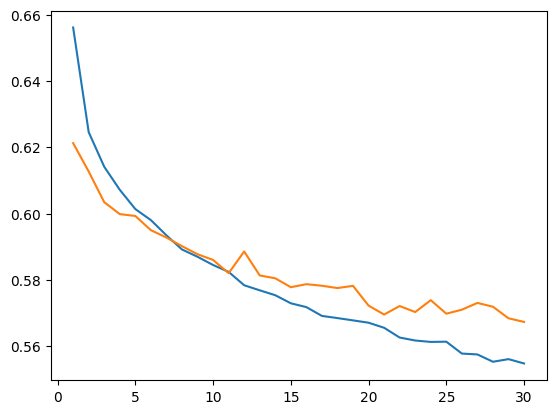

In [43]:
train_losses, val_losses = train_loop(classifier, feat_dir="D:/Phenologie/DL_Phenophases/vjepa/clstokens_DOFA_Mbal24_reshape", 
                                      out_path = "Z:/users/HadrienTulet/DL_pheno/vjepa/outputs/trained_classif_vjepa_Mbal24_clstokens30_AlibiEmbed.pth", 
                                      T=(3, 20), batch_size=8, loss_fn = loss_fn, lr=1e-5, N_epochs = 30, p_mask=0.05)

### Supervised_training

In [ ]:
NODATA_VALUE = 255
IGNORE_INDEX = 0

weights = [0.02, 0.58, 0.4]
loss_f = nn.CrossEntropyLoss(weight = torch.tensor(weights).cuda(), ignore_index = -1)
mask_fn = [d.split('.')[0] +"_mask_LDF.tif" for d in Mbal24_dates]

In [46]:
class CustomIntersectionDataset(Dataset):
    def __init__(self, feat_dataset: Dataset, mask_dataset: Dataset, bb_path: str):
        self.feat_dataset = feat_dataset
        self.mask_dataset = mask_dataset

        arr = np.load(bb_path, allow_pickle=True)
        bboxes = [BoundingBox(*row) for row in arr]

        self.feat_dataset.indices = self.feat_dataset.indices[::10]
        bboxes = bboxes[::10]

        assert len(bboxes) == len(feat_dataset)

        valid_pairs = [
            (orig_idx, bbox)
            for orig_idx, bbox in enumerate(bboxes)
            if list(mask_dataset.index.intersection(bbox_to_tuple(bbox), objects=True))
        ]

        n_dropped = len(bboxes) - len(valid_pairs)
        if n_dropped:
            pass
            # print(f"{n_dropped}/{len(bboxes)} bboxes located outside the mask extent were dropped")

        self.valid_feat_indices = [i   for i, _    in valid_pairs]
        self.bboxes       = [bb  for _, bb   in valid_pairs]

    
    def __len__(self):
        return len(self.bboxes)
    
    def __getitem__(self, idx):  
        bbox = self.bboxes[idx]
        feat_idx = self.valid_feat_indices[idx]

        mask_sample = self.mask_dataset[bbox]
        feat = self.feat_dataset[feat_idx]

        mask = mask_sample["mask"]
        mask[mask == NODATA_VALUE] = IGNORE_INDEX
        
        return feat, mask, bbox
    
class SegmHead(nn.Module):
    def __init__(self, tile_size, patch_size, embed_size, num_classes):
        super().__init__()
        self.patch_size = patch_size
        self.num_classes = num_classes
        self.projection = nn.Linear(embed_size, patch_size * patch_size * num_classes)      # after : num_patchs * logits d'un patch 1 dim (on garde la location des patchs)
        self.fold = nn.Fold(output_size=(tile_size, tile_size), kernel_size=patch_size, stride=patch_size)
    
    def forward(self, x):
        x = self.projection(x)
        x = x.permute(0, 2, 1)
        x = self.fold(x)
        return x
    
class MySegmentationModel(nn.Module):
    def __init__(self, classifier, seg_head):
        super(MySegmentationModel, self).__init__()
        self.classifier = classifier
        self.segmentation_head = seg_head

    def forward(self, x):
        features = self.classifier(x)
        output = self.segmentation_head(features)
        return output  

In [47]:
head = SegmHead(112, 8, 768, 4)

classifier = TemporalAggregator(embed_dim = 768, num_heads=16, num_layers=4, cls=False)
state_dict = torch.load("Z:/users/HadrienTulet/DL_pheno/vjepa/outputs/trained_classif_vjepa_Mbal24_clstokens30.pth", weights_only=False)
classifier.load_state_dict(state_dict, strict=True)

for name, param in classifier.named_parameters():
    param.requires_grad = False

model = MySegmentationModel(classifier, head)
model.cuda()

MySegmentationModel(
  (classifier): TemporalAggregator(
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-3): 4 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (linear1): Linear(in_features=768, out_features=2048, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=2048, out_features=768, bias=True)
          (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (segmentation_head): SegmHead(
    (projection): Linear(in_features=768, out_features=256, bias=True)
    (fold): Fold(output_size=(112, 112), kernel_size=8, dilation=1, padding=0, stride=8)
  )

In [48]:
class TileWindowSupervisedDataset(Dataset):
    """
    Loads one .npy file of shape (T_total, N, N_patches, embed_dim) and
    returns time series of features of size T.

    Each sample is:
        vec     — (T, N_patches, embed_dim)  input window
        tile_idx — int, for debugging / analysis
    """

    def __init__(self, filepath: str, T: Union[int, tuple], transform = None, p: float=0.2):
        # feat_data: (T_total, N, N_patches, embed_dim)
        
        self.data = torch.from_numpy(
            np.load(filepath, mmap_mode='r')
        )
        #print(self.data.shape)
        #self.data = self.data[:, ::10]
        #print(f"{os.path.basename(filepath)} : {self.data.shape}")
        
        self.T       = T
        self.T_total = self.data.shape[0]
        self.N       = self.data.shape[1]
        self.T_max = T[-1] if isinstance(T, tuple) else T
        self.transform = transform

        # build flat index: list of (tile_idx, t) pairs
        
        indices = [(n, self.T_max) for n in range(self.N)]

        self.indices = indices


    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        n, t = self.indices[idx]
        vec  = self.data[t - self.T_max : t, n]       # (T, N_patches, embed_dim)     #[t, t + self.T_max, n]

        if self.transform is not None:
            vec = self.transform(vec)

        return vec

def run_supervised_epoch(model, loader, optimizer, loss_fn, train: bool, scheduler = None):

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    classifier.train() if train else classifier.eval()
    total_loss, n_steps = 0.0, 0
    list_y_pred_val, list_y_val = [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            # data: (B, T, N_patches, embed_dim)
            # mask: (B, 1, tile_size, tile_size)
            vec    = batch['data'].to(DEVICE)
            labels = torch.tensor(batch['mask'], dtype = torch.int64)[:, 0].to(DEVICE).detach()     # stop-gradient on target
            #print(np.unique(labels.cpu().numpy()))
            predicted = model(vec)             # (B, N_patches, embed_dim)
            loss = loss_fn(predicted, labels.to(DEVICE))

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                if scheduler:
                    scheduler.step()
                    
            if not train:
                list_y_pred_val += list(torch.flatten(predicted.argmax(1)).detach().cpu().numpy())
                list_y_val+=list(torch.flatten(labels).cpu().numpy())

            total_loss += loss.item()
            n_steps    += 1

    return total_loss / n_steps, list_y_val, list_y_pred_val

def supervised_train_loop(model: nn.Module, feat_dir: str, bb_dir: str, mask_dir: str, out_path: str, loss_fn: nn.Module, batch_size: int, N_epochs: int, lr: float, T_max: int = 20, p_mask: float = 0.05, n_workers: int = 1):

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    features_files = sorted(os.listdir(feat_dir))
    sep = int(np.floor(3*len(features_files)/4))
    print(sep)
    train_files = features_files[:sep]#[:1]
    val_files = features_files[sep:]#[:1]

    bb_files = sorted(os.listdir(bb_dir))
    bb_train_files = bb_files[:sep]
    bb_val_files = bb_files[sep:]
    print("Train files : \n", train_files, "\nVal files : \n", val_files)

    #transforms = RandomZeroMask(p=p_mask)
    #transforms = None
    
    optimizer = Adam(model.parameters(), lr=lr)
    #scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    scheduler = None
    model.to(DEVICE)
    train_losses, val_losses = [], []
    for epoch in range(N_epochs):
        list_y_val, list_y_pred_val = [], []
        print(f"\nEpoch {epoch+1}/{N_epochs}")

        # Training
        train_loss = 0.0
        #print("Train : ")
        extensions = (".tif", ".tiff", ".TIF", ".TIFF")
        mask_fn = [f for f in os.listdir(mask_dir) if f.endswith(extensions)][30:54]

        val_loss = 0.0
        for i, fn in enumerate(tqdm(mask_fn)):
            T = min(i+1, T_max)

            def collate_random_T(batch):
                vecs, masks, bboxes = zip(*batch)
                if isinstance(T, tuple):
                    rd_T = np.random.randint(T[0], T[1])
                else:
                    rd_T = T
                vecs   = torch.stack([v[-rd_T:] for v in vecs])   # (B, T, N_patches, D)
                masks = torch.stack(list(masks))
                return {"data" : vecs, "mask" : masks, "bbox" : bboxes}
    
            class CustomMaskDataset(RasterDataset):
                filename_glob = fn
                is_image = False
                
            mask_dataset = CustomMaskDataset(mask_dir)

            for f, bbf in zip(train_files, bb_train_files):     #tzip
                feat_dataset = TileWindowSupervisedDataset(os.path.join(feat_dir, f), T=T)

                dataset = CustomIntersectionDataset(feat_dataset, mask_dataset, os.path.join(bb_dir, bbf))
                loader  = DataLoader(
                    dataset,
                    batch_size=batch_size,
                    shuffle=True,
                    collate_fn = collate_random_T,
                )
                L, _, _ = run_supervised_epoch(model, loader, optimizer, loss_fn, scheduler=scheduler, train=True)
                train_loss+= L
            
            # Val
            #print("\nValidation : ")
            for f, bbf in zip(val_files, bb_val_files):         #tzip
                feat_dataset = TileWindowSupervisedDataset(os.path.join(feat_dir, f), T=T)
                dataset = CustomIntersectionDataset(feat_dataset, mask_dataset, os.path.join(bb_dir, bbf))
                loader  = DataLoader(
                    dataset,
                    batch_size=batch_size,
                    shuffle=True,
                    collate_fn = collate_random_T,
                )
                L, y_val, y_pred_val = run_supervised_epoch(model, loader, optimizer, loss_fn, scheduler=scheduler, train=False)
                val_loss += L

                list_y_val.extend(y_val[::10])
                list_y_pred_val.extend(y_pred_val[::10])

        train_loss /= len(train_files) * len(mask_fn)
        train_losses.append(train_loss)

        val_loss /= len(val_files) * len(mask_fn)
        print(f"  train loss: {train_loss:.6f}  |  val loss: {val_loss:.6f}")

        val_losses.append(val_loss)
        if val_loss == np.min(val_losses):
            torch.save(model.state_dict, out_path)
        
        print(classification_report(list_y_val, list_y_pred_val, labels=np.unique(list_y_val)))
        print(confusion_matrix(list_y_val, list_y_pred_val, labels=np.unique(list_y_val)))

    X = np.array([i+1 for i in range(N_epochs)])
    plt.plot(X, train_losses)
    plt.plot(X, val_losses)
    plt.show()

    return train_losses, val_losses

In [ ]:
mask_dir = "D:/Phenologie/DL_Phenophases/data/Mbalmayo/new_masks"
mask_fn = [f for f in os.listdir(mask_dir) if f.endswith(extensions)][30:54]
fn = mask_fn[0]
T = 10

def collate_random_T(batch):
                vecs, masks, bboxes = zip(*batch)
                if isinstance(T, tuple):
                    rd_T = np.random.randint(T[0], T[1])
                else:
                    rd_T = T
                vecs   = torch.stack([v[-rd_T:] for v in vecs])   # (B, T, N_patches, D)
                masks = torch.stack(list(masks))
                return {"data" : vecs, "mask" : masks, "bbox":bboxes}

class CustomMaskDataset(RasterDataset):
    filename_glob = fn
    is_image = False
    
mask_dataset = CustomMaskDataset(mask_dir)
feat_dataset = TileWindowSupervisedDataset("D:/Phenologie/DL_Phenophases/vjepa/tokens_DOFA_Mbal24_reshape/chunk_0_features.npy", T=T)

dataset = CustomIntersectionDataset(feat_dataset, mask_dataset, bb_path="D:/Phenologie/DL_Phenophases/vjepa/bboxes/chunk_0_bboxes.npy")

dataloader = DataLoader(dataset,
                        batch_size=1,
                        shuffle=False,
                        collate_fn = collate_random_T,)

print(len(dataloader))

for batch in dataloader:
    print(batch["data"].shape)
    print(batch["mask"].shape)
    print(len(batch['bbox']))

In [ ]:
supervised_train_loop(model, feat_dir="D:/Phenologie/DL_Phenophases/vjepa/tokens_DOFA_Mbal24_reshape", 
                      bb_dir = "D:/Phenologie/DL_Phenophases/vjepa/bboxes",
                      out_path = "Z:/users/HadrienTulet/DL_pheno/vjepa/outputs/supervised/trained_classif_vjepa_Mbal24_clstokens30.pth",
                      mask_dir = "D:/Phenologie/DL_Phenophases/data/Mbalmayo/new_masks",
                      loss_fn = loss_f, batch_size = 4, N_epochs = 30, lr = 1e-5, T_max = 20)

17
Train files : 
 ['chunk_0_features.npy', 'chunk_10_features.npy', 'chunk_11_features.npy', 'chunk_12_features.npy', 'chunk_13_features.npy', 'chunk_14_features.npy', 'chunk_15_features.npy', 'chunk_16_features.npy', 'chunk_17_features.npy', 'chunk_18_features.npy', 'chunk_19_features.npy', 'chunk_1_features.npy', 'chunk_20_features.npy', 'chunk_21_features.npy', 'chunk_22_features.npy', 'chunk_2_features.npy', 'chunk_3_features.npy'] 
Val files : 
 ['chunk_4_features.npy', 'chunk_5_features.npy', 'chunk_6_features.npy', 'chunk_7_features.npy', 'chunk_8_features.npy', 'chunk_9_features.npy']

Epoch 1/30


  0%|          | 0/24 [00:00<?, ?it/s]C:\Users\tulet\AppData\Local\Temp\ipykernel_3324\4236214376.py:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(batch['mask'], dtype = torch.int64)[:, 0].to(DEVICE).detach()     # stop-gradient on target
100%|██████████| 24/24 [1:21:03<00:00, 202.64s/it]


  train loss: 0.778694  |  val loss: 0.687885


d:\tulet\envs\torch_gpu\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\tulet\envs\torch_gpu\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\tulet\envs\torch_gpu\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

          -1       0.00      0.00      0.00     16754
           0       0.83      0.00      0.00  10726787
           1       0.38      1.00      0.55   7117216
           2       0.02      0.00      0.00    185990
           3       0.03      0.00      0.00    541064

    accuracy                           0.38  18587811
   macro avg       0.25      0.20      0.11  18587811
weighted avg       0.62      0.38      0.21  18587811

[[       0        0    16376      268      110]
 [       0       90 10718544     4371     3782]
 [       0       17  7111920     2480     2799]
 [       0        1   185750      158       81]
 [       0        1   540707      176      180]]

Epoch 2/30


...

  0%|          | 0/24 [00:00<?, ?it/s]C:\Users\tulet\AppData\Local\Temp\ipykernel_3324\4236214376.py:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(batch['mask'], dtype = torch.int64)[:, 0].to(DEVICE).detach()     # stop-gradient on target
100%|██████████| 24/24 [1:43:46<00:00, 259.43s/it]


  train loss: 0.737356  |  val loss: 0.671538


d:\tulet\envs\torch_gpu\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\tulet\envs\torch_gpu\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\tulet\envs\torch_gpu\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

          -1       0.00      0.00      0.00     16759
           0       0.50      0.00      0.00  10726986
           1       0.38      1.00      0.55   7117021
           2       0.14      0.06      0.09    185924
           3       0.04      0.00      0.00    541121

    accuracy                           0.38  18587811
   macro avg       0.21      0.21      0.13  18587811
weighted avg       0.44      0.38      0.21  18587811

[[       0        0    16759        0        0]
 [       0        1 10678339    47262     1384]
 [       0        1  7093949    21348     1723]
 [       0        0   174083    11841        0]
 [       0        0   535885     5121      115]]

Epoch 11/30


  0%|          | 0/24 [00:00<?, ?it/s]C:\Users\tulet\AppData\Local\Temp\ipykernel_3324\4236214376.py:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(batch['mask'], dtype = torch.int64)[:, 0].to(DEVICE).detach()     # stop-gradient on target
 75%|███████▌  | 18/24 [52:00<31:10, 311.80s/it]

### Tests

In [7]:
train_data = np.load("Z:/users/HadrienTulet/DL_pheno/vjepa/dinov2_Mbal25_patchtokens_reshape/chunk_0_features.npy", mmap_mode='r')
train_data = torch.from_numpy(np.transpose(train_data, (1, 0, 2, 3)))
train_data.shape

val_data = np.load("Z:/users/HadrienTulet/DL_pheno/vjepa/dinov2_Mbal25_patchtokens_reshape/chunk_1_features.npy", mmap_mode='r')
val_data = torch.from_numpy(np.transpose(val_data, (1, 0, 2, 3)))
val_data.shape

C:\Users\tulet\AppData\Local\Temp\ipykernel_25616\3891279780.py:2: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:209.)
  train_data = torch.from_numpy(np.transpose(train_data, (1, 0, 2, 3)))


torch.Size([1021, 24, 196, 768])

In [ ]:
T = 20

feat_dir = "Z:/users/HadrienTulet/DL_pheno/vjepa/dinov2_Mbal25_patchtokens_reshape"
features_files = os.listdir(feat_dir)
sep = int(np.ceil(len(features_files)/4))
train_files = features_files[:sep]
val_files = features_files[sep:]

for f in train_files:
    print(f)
    feat_data = np.load(os.path.join(feat_dir, f))
    feat_data = torch.from_numpy(np.transpose(feat_data, (1, 0, 2, 3)))
    for t in range(feat_data.shape[1]-T):
        vec = feat_data[:, t:t+T]
        tgt_vec = feat_data[:, t+T]
        vec = vec.cuda()
        tgt_vec = tgt_vec.cuda()
        res = classifier(vec)
        loss = loss_fn(res, tgt_vec)
        print(res.shape)

for f in val_files:
    print(f)
    feat_data = np.load(os.path.join(feat_dir, f))
    feat_data = torch.from_numpy(np.transpose(feat_data, (1, 0, 2, 3)))
    for t in range(feat_data.shape[1]-T):
        vec = feat_data[:, t:t+T]
        tgt_vec = feat_data[:, t+T]
        vec = vec.cuda()
        tgt_vec = tgt_vec.cuda()
        res = classifier(vec)
        loss = loss_fn(res, tgt_vec)
        print(res.shape)

In [11]:
vec = train_data[0:2, :20]
tgt_vec = train_data[0:2, 20]
vec = vec.to("cuda")
tgt_vec = tgt_vec.to("cuda")

In [12]:
vec.shape

torch.Size([2, 20, 196, 768])

In [13]:
res = classifier(vec)
res.shape

torch.Size([2, 196, 768])